# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

## **Actividad de las Semanas 5 y 6**
### **Problema de asignación de créditos: South German Dataset.**


## **Nombres y matrículas:**



*   Nombre y matrícula

*   Nombre y matrícula

*   Nombre y matrícula



## **Ejercicio 1**

In [104]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:


import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import make_scorer
from imblearn.metrics import geometric_mean_score
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC




In [105]:
# Verificando versiones de algunas de las principales librerías.
# Si algunas no se utilizan, puedes comentarlas.
tmp = !python -V
print(tmp[0])
#print('Numpy', np.__version__)
print('Pandas', pd.__version__)
#print('Matplotlib', matplotlib.__version__)
print('Seaborn', sns.__version__)
print('Scikit-Learn', sklearn.__version__)
#print('XGBoost', xgboost.__version__)




Python 3.10.5
Pandas 2.2.3
Seaborn 0.13.2
Scikit-Learn 1.5.2


In [106]:
# Si deseas desplegar los Warnings:
#import warnings
#warnings.filterwarnings('ignore')

In [107]:
# Carga los datos del archivo SouthGermanCredit.asc:

# ************* Inlcuye aquí tu código:*****************************
df = pd.read_csv("D:\\Mestria\\ML\\Tarea\\SouthGermanCredit.asc", delimiter=" ", skipinitialspace=True)  # Usa "\t" para tabulación, o ";" si es otro delimitador

# *********** Aquí termina la sección de agregar código *************


print('Dimensión del DataFrame (registros,variables):', df.shape)
df.head(3).T

Dimensión del DataFrame (registros,variables): (1000, 21)


,0,1,2
laufkont,1,1,2
laufzeit,18,9,12
moral,4,4,2
verw,2,0,9
hoehe,1049,2799,841
sparkont,1,1,2
beszeit,2,3,4
rate,4,2,2
famges,2,3,2
buerge,1,1,1


In [108]:
# Renombra las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:

# ************* Inlcuye aquí tu código:*****************************
column_names = [
    "status", "duration", "credit_history", "purpose", "amount",
    "savings", "employment_duration", "installment_rate",
    "personal_status_sex", "other_debtors",
    "present_residence", "property",
    "age", "other_installment_plans",
    "housing", "number_credits",
    "job", "people_liable", "telephone", "foreign_worker",
    "credit_risk"
]

# Asignar los nombres correctos
df.columns = column_names

# Definir los mapeos para las variables categóricas
#Esto solo se hace si se quiere cambiar a los valores cateforicos
dic = {
    "status": {1: "no checking account", 2: "< 0 DM", 3: "0 <= ... < 200 DM", 4: ">= 200 DM / salary for at least 1 year"},
    "credit_history": {0: "delay in paying off in the past", 1: "critical account/other credits elsewhere",
                       2: "no credits taken/all credits paid back duly", 3: "existing credits paid back duly till now",
                       4: "all credits at this bank paid back duly"},
    "purpose": {0: "others", 1: "car (new)", 2: "car (used)", 3: "furniture/equipment", 4: "radio/television",
                5: "domestic appliances", 6: "repairs", 7: "education", 8: "vacation", 9: "retraining", 10: "business"},
    "savings": {1: "unknown/no savings account", 2: "< 100 DM", 3: "100 <= ... < 500 DM",
                4: "500 <= ... < 1000 DM", 5: ">= 1000 DM"},
    "employment_duration": {1: "unemployed", 2: "< 1 yr", 3: "1 <= ... < 4 yrs",
                            4: "4 <= ... < 7 yrs", 5: ">= 7 yrs"},
    "installment_rate": {1: ">= 35", 2: "25 <= ... < 35", 3: "20 <= ... < 25", 4: "< 20"},
    "personal_status_sex": {1: "male : divorced/separated", 2: "female : non-single or male : single",
                            3: "male : married/widowed", 4: "female : single"},
    "other_debtors": {1: "none", 2: "co-applicant", 3: "guarantor"},
    "present_residence": {1: "< 1 yr", 2: "1 <= ... < 4 yrs", 3: "4 <= ... < 7 yrs", 4: ">= 7 yrs"},
    "property": {1: "unknown / no property", 2: "car or other",
                 3: "building soc. savings agr./life insurance", 4: "real estate"},
    "other_installment_plans": {1: "bank", 2: "stores", 3: "none"},
    "housing": {1: "for free", 2: "rent", 3: "own"},
    "number_credits": {1: "1", 2: "2-3", 3: "4-5", 4: ">= 6"},
    "job": {1: "unemployed/unskilled - non-resident", 2: "unskilled - resident",
            3: "skilled employee/official", 4: "manager/self-empl./highly qualif. employee"},
    "people_liable": {1: "3 or more", 2: "0 to 2"},
    "telephone": {1: "no", 2: "yes (under customer name)"},
    "foreign_worker": {1: "yes", 2: "no"},
    "credit_risk": {0: "bad", 1: "good"}
}

# Aplicar los mapeos a las columnas categóricas
for col, x in dic.items():
    df[col] = df[col].map(x)


# *********** Aquí termina la sección de agregar código *************


df.head(3).T

,0,1,2
status,no checking account,no checking account,< 0 DM
duration,18,9,12
credit_history,all credits at this bank paid back duly,all credits at this bank paid back duly,no credits taken/all credits paid back duly
purpose,car (used),others,retraining
amount,1049,2799,841
savings,unknown/no savings account,unknown/no savings account,< 100 DM
employment_duration,< 1 yr,1 <= ... < 4 yrs,4 <= ... < 7 yrs
installment_rate,< 20,25 <= ... < 35,25 <= ... < 35
personal_status_sex,female : non-single or male : single,male : married/widowed,female : non-single or male : single
other_debtors,none,none,none


## **Ejercicio 2**

In [109]:
# De la documentación de los datos SouthGermandata se sabe que la clase mayoritaria
# de los buenos clientes se etiquetó con el valor de 1 en la variable de salida
# llamada "credit_risk".
# Veamos:

print(df['credit_risk'].value_counts())

credit_risk
good    700
bad     300
Name: count, dtype: int64


In [110]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,no checking account,18,all credits at this bank paid back duly,car (used),1049,unknown/no savings account,< 1 yr,< 20,female : non-single or male : single,none,...,car or other,21,none,for free,1,skilled employee/official,0 to 2,no,no,good
1,no checking account,9,all credits at this bank paid back duly,others,2799,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,36,none,for free,2-3,skilled employee/official,3 or more,no,no,good
2,< 0 DM,12,no credits taken/all credits paid back duly,retraining,841,< 100 DM,4 <= ... < 7 yrs,25 <= ... < 35,female : non-single or male : single,none,...,unknown / no property,23,none,for free,1,unskilled - resident,0 to 2,no,no,good
3,no checking account,12,all credits at this bank paid back duly,others,2122,unknown/no savings account,1 <= ... < 4 yrs,20 <= ... < 25,male : married/widowed,none,...,unknown / no property,39,none,for free,2-3,unskilled - resident,3 or more,no,yes,good
4,no checking account,12,all credits at this bank paid back duly,others,2171,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,...,car or other,38,bank,rent,2-3,unskilled - resident,0 to 2,no,yes,good


In [111]:
# Por lo tanto, realiza a continuación una transformación para que la clase mayoritaria
# sea la clase negativa (es decir, de valor 0) y que la clase minoritaria sea la
# clase positiva (es decir, de valor 1).


# ************* Inlcuye aquí tu código:*****************************

df["credit_risk"] = df["credit_risk"].replace({"good": "bad", "bad": "good"})

# Convertir credit_risk a valores numéricos
df['credit_risk'] = df['credit_risk'].map({'good': 1, 'bad': 0})

#print(df['credit_risk'].dtype)
# *********** Aquí termina la sección de agregar código *************


print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64


## **Ejercicio 3**

In [112]:
# Ejercicio 3a.
# Realiza una partición con el porcentaje solicitado para entrenamiento y prueba.
# Los nombres de los conjuntos deberán ser como se indican en los print de abajo:

# ************* Inlcuye aquí tu código:*****************************

X = df.drop(columns=['credit_risk'])  # Elimina la variable objetivo
y = df['credit_risk']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)


# *********** Aquí termina la sección de agregar código *************


# Mostremos las dimensiones de la partición generada:
print("Dimensiones:")
print("Entrenamiento:", Xtrain.shape, ytrain.shape)
print("Prueba:", Xtest.shape, ytest.shape)

# Y el porcentaje de cada clase de la variable de salida:
tmp = (ytrain.sum()/ytrain.shape[0])
print("\nPorcentaje clases Negativa (buenos clientes-0):%.2f%%, y Positiva (malos clientes-1):%.2f%%" % (100*(1-tmp),tmp*100))


Dimensiones:
Entrenamiento: (800, 20) (800,)
Prueba: (200, 20) (200,)

Porcentaje clases Negativa (buenos clientes-0):70.25%, y Positiva (malos clientes-1):29.75%


### **Ejercicio 3b**
### **Con base al porcentaje de los niveles de la variable de salida ¿podemos decir que tenemos un problema de datos desbalanceado? ¿Por qué?**



### ++++++++ Inicia la sección de agregar texto: +++++++++++

None

### ++++++++ Termina la sección de agregar texto: +++++++++++



### **Ejercicio 3c**
### **¿Por qué se hizo el cambio de etiquetas 0 y 1 en la variable de salida?**



### ++++++++ Inicia la sección de agregar texto: +++++++++++

None

### ++++++++ Termina la sección de agregar texto: +++++++++++


## **Ejercicio 4**

In [113]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE asociado a
# esta Actividad, define a continuación las variables de entrada correspondientes
# de acuerdo a su tipo y como se indica a continuación:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
lista_paper_num = ['duration', 'amount', 'age']

# Variables ordinales:
lista_paper_ord = ['employment_duration', 'installment_rate', 'present_residence', 'property', 'number_credits', 'job']

# Variables nominales & binarias:
lista_paper_cat = ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors', 'other_installment_plans', 'housing', 'people_liable', 'telephone', 'foreign_worker']


# *********** Aquí termina la sección de agregar código *************

print("Para los datos de entrada, veamos la cantidad de cada tipo de variable obtenida:")
print("Variables numéricas:", len(lista_paper_num))
print("Variables ordinales:", len(lista_paper_ord))
print("Variables nominales & binarias:", len(lista_paper_cat))


Para los datos de entrada, veamos la cantidad de cada tipo de variable obtenida:
Variables numéricas: 3
Variables ordinales: 6
Variables nominales & binarias: 11


## **Ejercicio 5**

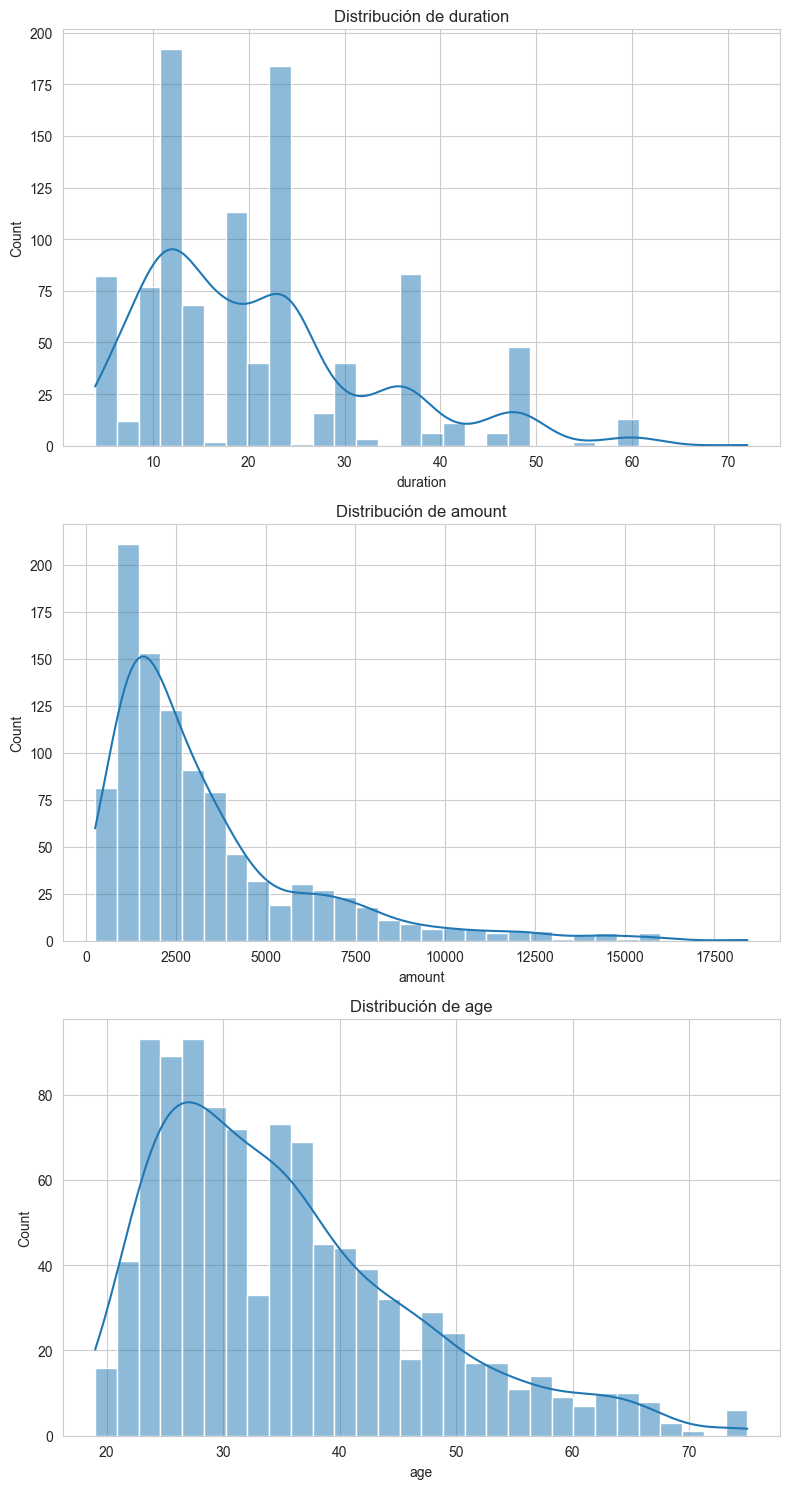

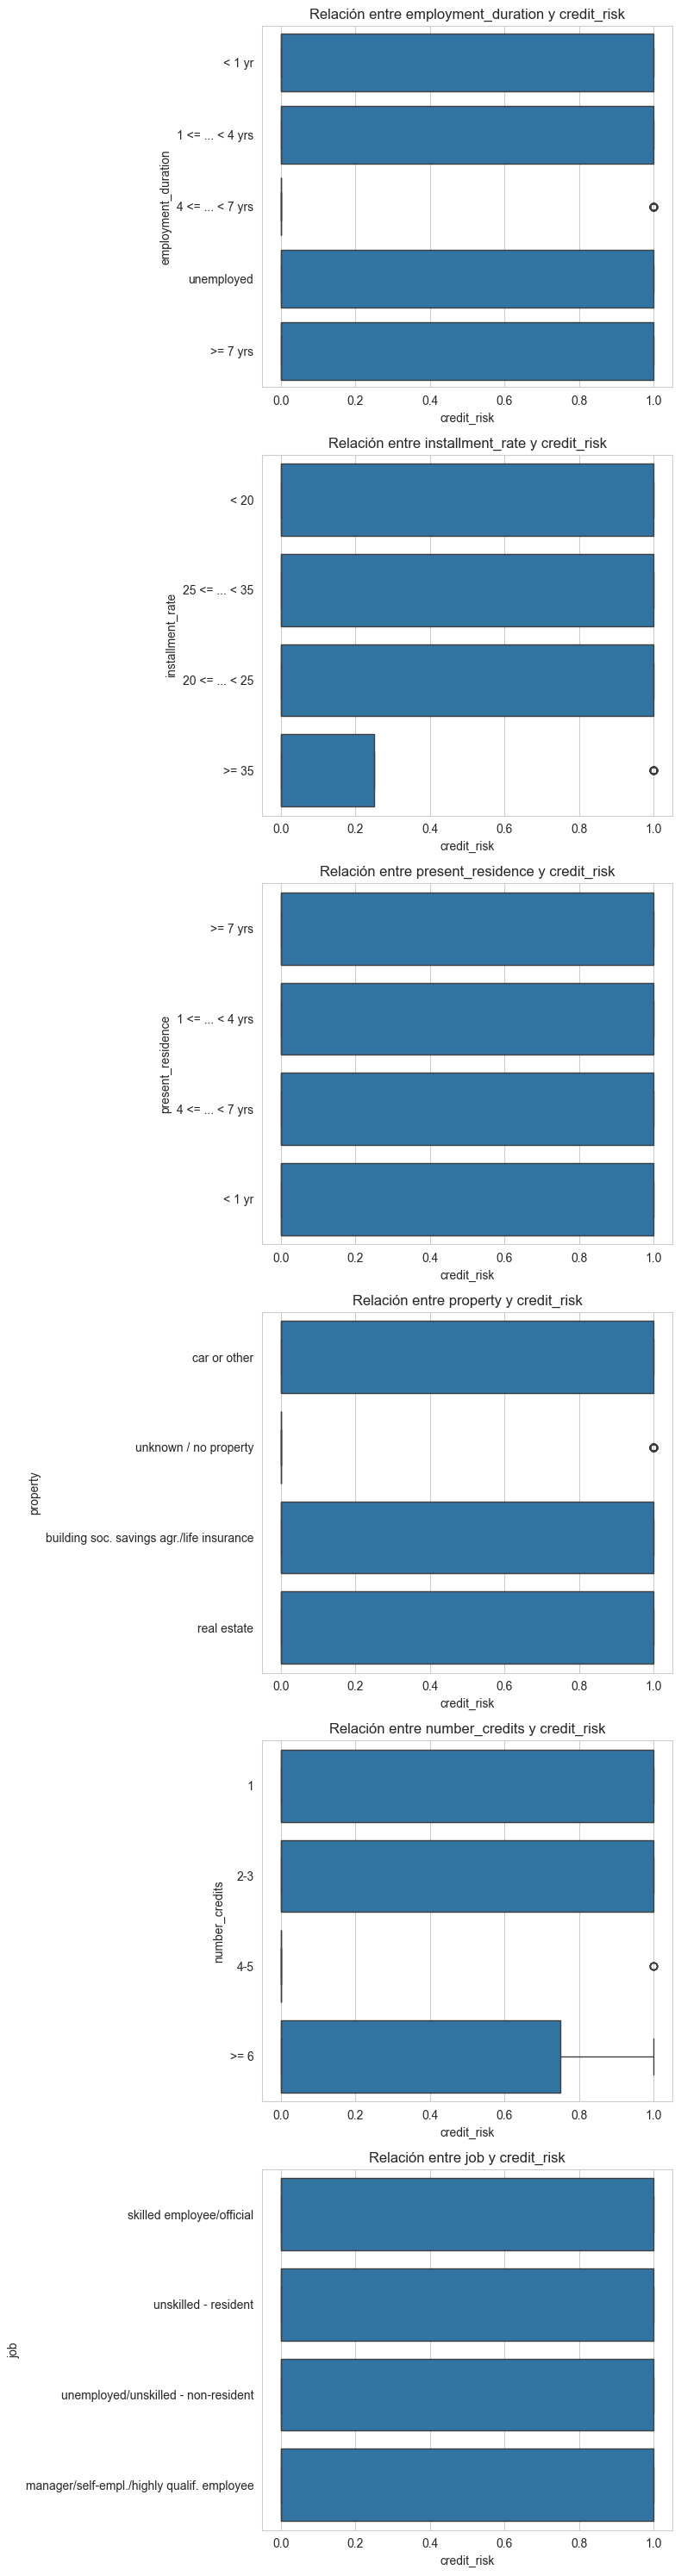

Variables numéricas


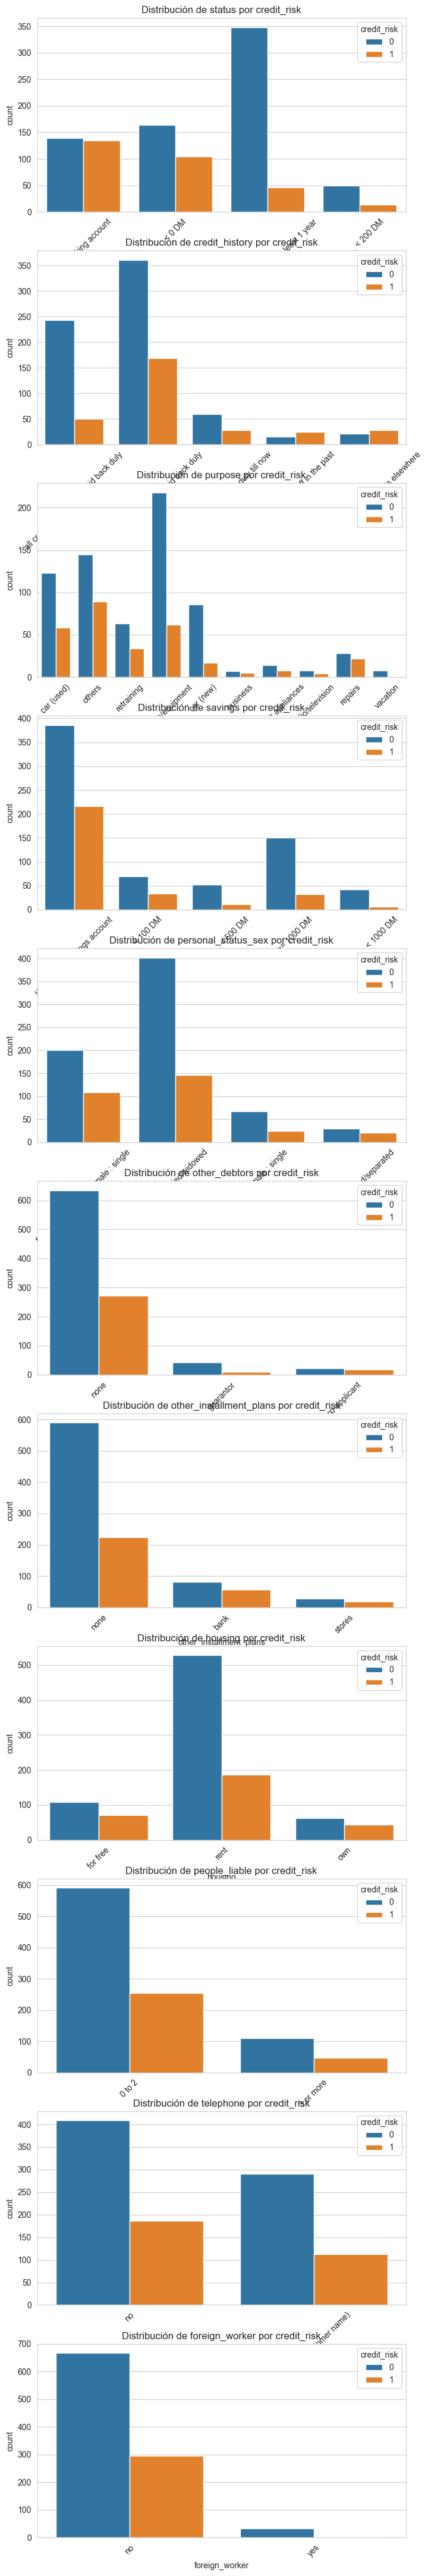

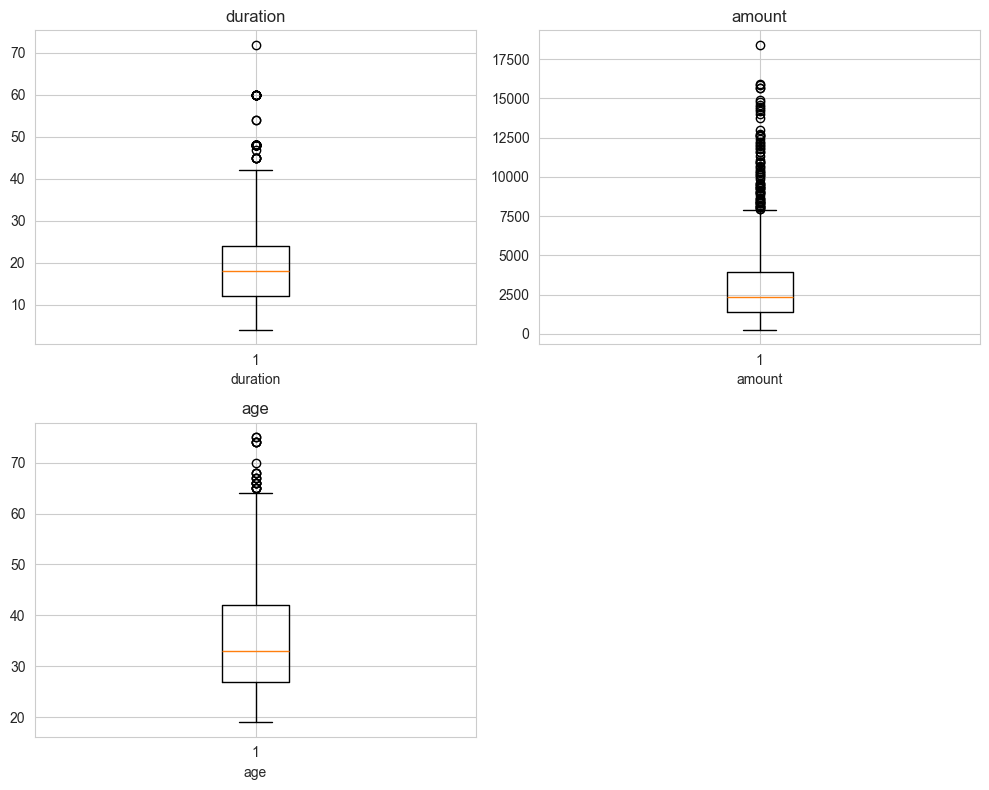

<Figure size 640x480 with 0 Axes>

In [114]:
# En esta sección puedes incluir todas las celdas que consideres necesarias para
# visualizar o bien obtener información de cada tipo de variable y te ayude a
# determinar qué transformaciones aplicarás a cada una en el módulo de Pipeline.

# Configuración de estilo
sns.set_style("whitegrid")

# --- Visualización de variables numéricas ---
fig, axes = plt.subplots(len(lista_paper_num), 1, figsize=(8, 5 * len(lista_paper_num)))

for i, var in enumerate(lista_paper_num):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
    
plt.tight_layout()
plt.show()

# --- Visualización de variables ordinales (Boxplots por credit_risk) ---
fig, axes = plt.subplots(len(lista_paper_ord), 1, figsize=(8, 5 * len(lista_paper_ord)))

for i, var in enumerate(lista_paper_ord):
    sns.boxplot(x=df['credit_risk'], y=df[var], data=df, ax=axes[i])
    axes[i].set_title(f'Relación entre {var} y credit_risk')

plt.tight_layout()
plt.show()

# --- Visualización de variables categóricas y binarias ---
fig, axes = plt.subplots(len(lista_paper_cat), 1, figsize=(8, 5 * len(lista_paper_cat)))

for i, var in enumerate(lista_paper_cat):
    sns.countplot(x=df[var], hue=df['credit_risk'], data=df, ax=axes[i])
    axes[i].set_title(f'Distribución de {var} por credit_risk')
    axes[i].tick_params(axis='x', rotation=45)  # Rotar etiquetas si es necesario

print("Variables numéricas")
plt.figure (figsize= (10,8))
for x, ind in enumerate(lista_paper_num):
  plt.subplot(2,2,x+1)
  plt.boxplot(df[ind])
  plt.title(ind)
  plt.xlabel(ind)
plt.tight_layout()
plt.show()    

plt.tight_layout()
plt.show()



In [115]:
# Una vez analizados los datos de entrada, las transformaciones que se aplicarán
# a cada tipo de variable usando la clase Pipeline de sklearn son las siguientes:


# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
numericas_pipe = Pipeline([
    ('scaler', StandardScaler())
])
numericas_pipe_nombres = lista_paper_num

# Variables categóricas-Nominales:
nominales_pipe = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
nominales_pipe_nombres = lista_paper_cat

# Variables categóricas-ordinales:
ordinales_pipe = Pipeline([
    ('ordinal', OrdinalEncoder())
])
ordinales_pipe_nombres = lista_paper_ord


# Conjuntas las transformaciones de todo tipo de variable y
# deja sin procesar aquellas que hayas decidido no transformar:
columnasTransformer = ColumnTransformer([
    ('num', numericas_pipe, numericas_pipe_nombres),
    ('nom', nominales_pipe, nominales_pipe_nombres),
    ('ord', ordinales_pipe, ordinales_pipe_nombres)
])


# *********** Aquí termina la sección de agregar código *************



Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Dimensión de los datos de entrada:")
print("antes de aplicar las transformaciones:", Xtmp.shape)
print("después de aplicar las transformaciones:", tmp.shape)


Dimensión de los datos de entrada:
antes de aplicar las transformaciones: (800, 20)
después de aplicar las transformaciones: (800, 52)


## **Ejercicio 6**

In [116]:
# Como se va a utilizar Validación-Cruzada, concatena los conjuntos de entrenamiento
# y prueba en uno nuevo conjunto aumentado que llamaremos trainval:


# ************* Inlcuye aquí tu código:**************************


# Concatenación para Validación Cruzada
Xtraintest = np.vstack([Xtrain, Xtest])
ytraintest = np.hstack([ytrain, ytest])

# Convertir Xtraintest a DataFrame antes de aplicar transformaciones
Xtraintest = pd.DataFrame(Xtraintest, columns=Xtrain.columns)

# Aplicar transformación nuevamente
Xtmp = Xtraintest.copy()
tmp = columnasTransformer.fit_transform(Xtmp)



# *********** Aquí termina la sección de agregar código *************


# Veamos cuántas variables nuevas se introducen con las transformaciones One-Hot-Encoding:
Xtmp = Xtraintest.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Dimensión de las variables de entrada ANTES de las transformaciones:", Xtmp.shape)
print("Dimensión de las variables de entrada DESPUÉS de las transformaciones:", tmp.shape)

Dimensión de las variables de entrada ANTES de las transformaciones: (1000, 20)
Dimensión de las variables de entrada DESPUÉS de las transformaciones: (1000, 52)


## **Ejercicio 7**

In [117]:
# Diccionario global para almacenar las métricas
metricas_resultados = {}

def mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo=None):
    """
    Se lleva a cabo el proceso de entrenamiento y evaluación con diferentes métricas.
    Guarda los resultados en un diccionario global para su posterior análisis.
    """

    pipeline = ImbPipeline(steps=[
        ('sub_sobre_muestreo', metodo_uo),
        ('model', modelo)
    ])

    micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)
    mismetricas = {
        'miaccuracy': 'accuracy',
        'miprecision': 'precision',
        'mirecall': 'recall',
        'mifi': 'f1',
        'miauc': 'roc_auc',
        'migmean': make_scorer(geometric_mean_score)
    }

    scores = cross_validate(pipeline, Xtraintest, np.ravel(ytraintest), scoring=mismetricas, cv=micv, return_train_score=True)

    # Guardar métricas en el diccionario global
    metricas_resultados[nombre] = {
        "Accuracy": np.nanmean(scores['test_miaccuracy']),
        "Precision": np.nanmean(scores['test_miprecision']),
        "Recall": np.nanmean(scores['test_mirecall']),
        "F1-Score": np.nanmean(scores['test_mifi']),
    }

    print(f'>> {nombre}')
    for j, k in enumerate(list(scores.keys())):
        if j > 1:
            print(f'\t{k}: {np.nanmean(scores[k]):.4f} ({np.nanstd(scores[k]):.3f})')



### **Ejercicio 7a: Regresión Logística**

In [118]:
# Invertir el mapeo del diccionario 'dic' para recuperar los valores numéricos originales
inverse_dic = {col: {v: k for k, v in mapping.items()} for col, mapping in dic.items()}

In [119]:
# Regresión Logística - Logistic Regression-LR:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

# Puedes consultar la siguiente liga para los métodos de submuestreo o sobremuestreo:
# https://imbalanced-learn.org/stable/references/over_sampling.html

# ************* Inlcuye aquí tu código:**************************

nombre = "Regresión_Logística"

# Selecciona la configuración de valores de hiperparámetros que consideres
# te da el mejor desempeño:

# Aplicar la conversión a Xtraintest para restaurar los valores numéricos originales
Xtraintest = Xtraintest.replace(inverse_dic)

# Aplicar ColumnTransformer para transformar las variables categóricas en numéricas
Xtraintest_transformed = columnasTransformer.fit_transform(Xtraintest)

# Aplicar SMOTE a los datos transformados
metodo_uo = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = metodo_uo.fit_resample(Xtraintest_transformed, ytraintest)


# Definir modelo de Regresión Logística con hiperparámetros óptimos
modelo = LogisticRegression(solver='liblinear', C=1.0, max_iter=100)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo,nombre, Xtraintest, ytraintest, metodo_uo)


C:\Users\52614\AppData\Local\Temp\ipykernel_188\783870042.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xtraintest = Xtraintest.replace(inverse_dic)


>> Regresión_Logística
	test_miaccuracy: 0.7603 (0.020)
	train_miaccuracy: 0.7740 (0.007)
	test_miprecision: 0.6299 (0.048)
	train_miprecision: 0.6533 (0.017)
	test_mirecall: 0.4944 (0.061)
	train_mirecall: 0.5264 (0.014)
	test_mifi: 0.5516 (0.046)
	train_mifi: 0.5829 (0.013)
	test_miauc: 0.7817 (0.028)
	train_miauc: 0.8055 (0.006)
	test_migmean: 0.6560 (0.039)
	train_migmean: 0.6806 (0.010)


### **Ejercicio 7b: k-Vecinos Más Cercanos (kNN)**

In [120]:
# k-Vecinos más Cercanos : k-Nearest-Neighbors-kNN:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


# ************* Inlcuye aquí tu código:**************************
### **Ejercicio 7b: k-Vecinos Más Cercanos (kNN)**
nombre: "kNN_22_Euclidean_Distance_0.5"
modelo: KNeighborsClassifier(n_neighbors=22, metric='minkowski', p=2, weights='distance')
metodo_uo: SMOTE(sampling_strategy=0.5, random_state=42)



# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> Regresión_Logística
	test_miaccuracy: 0.7603 (0.020)
	train_miaccuracy: 0.7740 (0.007)
	test_miprecision: 0.6299 (0.048)
	train_miprecision: 0.6533 (0.017)
	test_mirecall: 0.4944 (0.061)
	train_mirecall: 0.5264 (0.014)
	test_mifi: 0.5516 (0.046)
	train_mifi: 0.5829 (0.013)
	test_miauc: 0.7817 (0.028)
	train_miauc: 0.8055 (0.006)
	test_migmean: 0.6560 (0.039)
	train_migmean: 0.6806 (0.010)


### **Ejercicio 7c: Arbol de decisiones**

In [121]:
# Árbol de decisiones-DecisionTree-DT:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


# ************* Inlcuye aquí tu código:**************************
# 🔹 Aplicar SMOTE para balancear clases
metodo_uo = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = metodo_uo.fit_resample(Xtraintest_transformed, ytraintest)

# 🔹 Definir modelo Árbol de Decisión
nombre = "Árbol de Decisión"
modelo = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> Árbol de Decisión
	test_miaccuracy: 0.6900 (0.036)
	train_miaccuracy: 0.9400 (0.011)
	test_miprecision: 0.4863 (0.059)
	train_miprecision: 0.9191 (0.037)
	test_mirecall: 0.4700 (0.063)
	train_mirecall: 0.8797 (0.034)
	test_mifi: 0.4759 (0.053)
	train_mifi: 0.8980 (0.019)
	test_miauc: 0.6461 (0.051)
	train_miauc: 0.9855 (0.005)
	test_migmean: 0.6054 (0.044)
	train_migmean: 0.9215 (0.016)


### **Ejercicio 7d: Bosque Aleatorio - Random Forest**

In [ ]:
# Bosque Aleatorio-RandomForest-RF:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


# ************* Inlcuye aquí tu código:**************************
# Diccionario para almacenar los resultados


### **Ejercicio 7d: Bosque Aleatorio - Random Forest**  
nombre: "RF_40_Gini_Depth3_0.5" 
modelo:RandomForestClassifier(n_estimators=40, criterion='gini', max_depth=3, max_features='sqrt', min_samples_split=5, min_samples_leaf=3, random_state=42),
metodo_uo: SMOTE(sampling_strategy=0.5, random_state=42)

 







# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
#mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> RF_30_Entropy_Depth3_0.5
	test_miaccuracy: 0.7187 (0.016)
	train_miaccuracy: 0.7537 (0.007)
	test_miprecision: 0.6886 (0.151)
	train_miprecision: 0.8864 (0.031)
	test_mirecall: 0.1178 (0.044)
	train_mirecall: 0.2061 (0.030)
	test_mifi: 0.1981 (0.068)
	train_mifi: 0.3331 (0.038)
	test_miauc: 0.7651 (0.026)
	train_miauc: 0.8317 (0.008)
	test_migmean: 0.3325 (0.066)
	train_migmean: 0.4501 (0.032)
>> RF_20_Gini_Depth3_0.5
	test_miaccuracy: 0.7217 (0.019)
	train_miaccuracy: 0.7592 (0.009)
	test_miprecision: 0.6714 (0.133)
	train_miprecision: 0.8563 (0.033)
	test_mirecall: 0.1456 (0.045)
	train_mirecall: 0.2383 (0.037)
	test_mifi: 0.2370 (0.067)
	train_mifi: 0.3710 (0.042)
	test_miauc: 0.7633 (0.028)
	train_miauc: 0.8279 (0.006)
	test_migmean: 0.3711 (0.058)
	train_migmean: 0.4824 (0.035)
>> RF_40_Gini_Depth4_0.5
	test_miaccuracy: 0.7367 (0.025)
	train_miaccuracy: 0.7942 (0.009)
	test_miprecision: 0.6690 (0.108)
	train_miprecision: 0.8718 (0.028)
	test_mirecall: 0.2467 (0.059)
	train_mire

### **Ejercicio 7e: XGBoosting**

In [ ]:
# XGBoosting:
# https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBClassifier
# https://xgboost.readthedocs.io/en/stable/parameter.html


# ************* Inlcuye aquí tu código:**************************

# 🔹 Convertir todas las columnas numéricas de Xtraintest a float antes de la transformación
Xtraintest[lista_paper_num] = Xtraintest[lista_paper_num].apply(pd.to_numeric, errors='coerce')

# 🔹 Verificar tipos después de conversión

# 🔹 Aplicar ColumnTransformer para transformar variables categóricas
Xtraintest_transformed = columnasTransformer.fit_transform(Xtraintest)

# 🔹 Convertir a DataFrame nuevamente para verificar
Xtraintest_transformed = pd.DataFrame(Xtraintest_transformed)


# 🔹 Aplicar SMOTE
metodo_uo = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = metodo_uo.fit_resample(Xtraintest_transformed, ytraintest)

# 🔹 Convertir a numpy antes de XGBoost
X_resampled = np.array(X_resampled, dtype=np.float32)
y_resampled = np.array(y_resampled, dtype=np.int32)

# 🔹 Definir modelo XGBoost con enable_categorical=True
modelo = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.1, 
                       random_state=42, use_label_encoder=False, 
                       eval_metric='logloss', enable_categorical=True)



# Ejecutar cada configuración y almacenar resultados
for config in configuraciones_rf_X:
    nombre = config["nombre"]
    modelo = config["modelo"]
    metodo_uo = config["metodo_uo"]
    mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [06:56:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [06:56:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [06:56:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are

>> RF_50_Entropy_Depth15_0.7
	test_miaccuracy: 0.7540 (0.018)
	train_miaccuracy: 1.0000 (0.000)
	test_miprecision: 0.6091 (0.046)
	train_miprecision: 1.0000 (0.000)
	test_mirecall: 0.5178 (0.051)
	train_mirecall: 1.0000 (0.000)
	test_mifi: 0.5573 (0.033)
	train_mifi: 1.0000 (0.000)
	test_miauc: 0.7760 (0.025)
	train_miauc: 1.0000 (0.000)
	test_migmean: 0.6642 (0.028)
	train_migmean: 1.0000 (0.000)


c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [06:56:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### **Ejercicio 7f: Red Neuronal Multicapa (MLP)**

In [124]:
# Red neuronal de Perceptrón Multicapa-MLP:
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html


# ************* Inlcuye aquí tu código:**************************

# 🔹 Aplicar SMOTE para balancear clases
metodo_uo = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = metodo_uo.fit_resample(Xtraintest_transformed, ytraintest)

# 🔹 Definir modelo Red Neuronal Multicapa (MLP)
nombre = "Red Neuronal Multicapa (MLP)"
modelo = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=500, random_state=42)
# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

>> Red Neuronal Multicapa (MLP)
	test_miaccuracy: 0.6723 (0.087)
	train_miaccuracy: 0.6728 (0.089)
	test_miprecision: 0.3548 (0.345)
	train_miprecision: 0.4880 (0.357)
	test_mirecall: 0.2244 (0.289)
	train_mirecall: 0.2186 (0.290)
	test_mifi: 0.2026 (0.216)
	train_mifi: 0.1966 (0.207)
	test_miauc: 0.6008 (0.081)
	train_miauc: 0.6332 (0.061)
	test_migmean: 0.2623 (0.251)
	train_migmean: 0.2591 (0.237)


### **Ejercicio 7g: Máquina de Vector Soporte (SVM)**

In [125]:
# Máquina de Vectores de Soporte-SVM:
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html


# ************* Inlcuye aquí tu código:**************************

# 🔹 Aplicar SMOTE para balancear clases
metodo_uo = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = metodo_uo.fit_resample(Xtraintest_transformed, ytraintest)

# 🔹 Convertir a numpy arrays para compatibilidad con SVM
X_resampled = np.array(X_resampled, dtype=np.float32)
y_resampled = np.array(y_resampled, dtype=np.int32)

# 🔹 Definir modelo Máquina de Vector Soporte (SVM)
nombre = "Máquina de Vector Soporte (SVM)"
modelo = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# *********** Aquí termina la sección de agregar código *************


# Evaluemos la configuración seleccionada:
mi_fun(modelo, nombre, Xtraintest, ytraintest, metodo_uo)


>> Máquina de Vector Soporte (SVM)
	test_miaccuracy: 0.7077 (0.016)
	train_miaccuracy: 0.7097 (0.003)
	test_miprecision: 0.5998 (0.197)
	train_miprecision: 0.6335 (0.051)
	test_mirecall: 0.0756 (0.037)
	train_mirecall: 0.0789 (0.014)
	test_mifi: 0.1326 (0.062)
	train_mifi: 0.1398 (0.023)
	test_miauc: 0.5798 (0.029)
	train_miauc: 0.5940 (0.022)
	test_migmean: 0.2628 (0.070)
	train_migmean: 0.2768 (0.025)


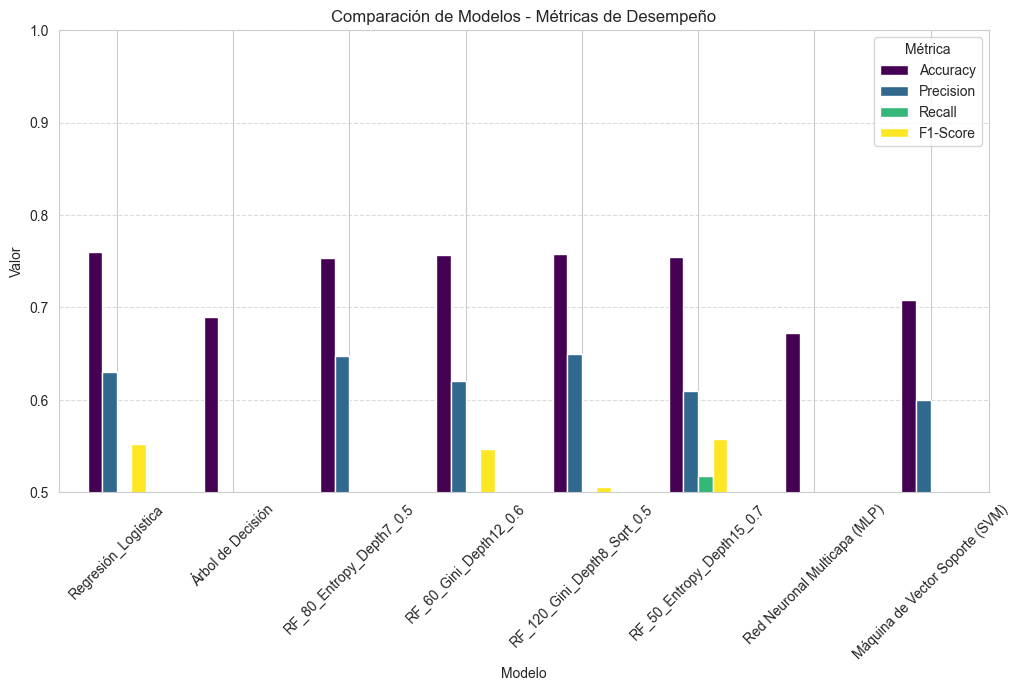

In [126]:
def graficar_metricas():
    df_metricas = pd.DataFrame.from_dict(metricas_resultados, orient="index")
    fig, ax = plt.subplots(figsize=(12, 6))
    df_metricas.plot(kind="bar", ax=ax, colormap="viridis")
    
    ax.set_title("Comparación de Modelos - Métricas de Desempeño")
    ax.set_ylabel("Valor")
    ax.set_xlabel("Modelo")
    ax.set_ylim(0.5, 1)
    ax.legend(title="Métrica")
    
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

graficar_metricas()


## **Ejercicio 8**

In [127]:
# Incluye el reporte del mejor modelo solicitado en el archivo PDF:

None

## **Ejercicio 9**

### **Escribe tus conclusiones finales de la actividad.**

### ++++++++ Inicia la sección de agregar texto: +++++++++++

None


### ++++++++ Termina la sección de agregar texto. +++++++++++


>> ### **Fin de la Actividad de las Semanas 5 y 6.**